## **Section 1: Importing Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

## **SECTION 2: Initialization**

In [13]:
df = pd.read_csv(r"C:\Users\Bal\OneDrive\Desktop\My Data Analysis\EDA - Real Estate\Data\Data_Cleaned.csv")
# We make sure the results are not cut or truncated
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## **SECTION 3: Data Overview**

In [14]:
display(df.shape)
df.head(10)

(1496, 9)

,Location,price_php_millions,Bedrooms,Bathrooms,Floor Area,Land Area,Town/Barangay,Municipality/City,Province/NCR
0,"Santo Domingo, Cainta",9.50,4.0,3.0,144.00,136.0,Santo Domingo,Cainta,Rizal
1,"San Vicente, Santa Maria",4.40,3.0,2.0,63.20,80.0,San Vicente,Santa Maria,Bulacan
2,"Camella Tarlac Access Rd. Maliwalo, Tarlac",7.81,5.0,3.0,100.00,110.0,Maliwalo,Tarlac City,Tarlac
3,"Gabon, Abucay",NaN,3.0,2.0,67.00,88.0,Gabon,Abucay,Bataan
4,"Zambowood Rd. Boalan, Zamboanga",3.28,2.0,1.0,40.32,78.4,Boalan,Zamboanga City,Zamboanga del Sur
5,"Remulla Drive Tanza-Naic Rd. Sahud Ulan, Tanza",3.17,NaN,NaN,39.64,100.0,Sahud Ulan,Tanza,Cavite
6,"Santa Maria-San Jose Rd. Bulac, Santa Maria",1.80,2.0,2.0,52.00,40.0,Bulac,Santa Maria,Bulacan
7,"Aningway Sacatihan, Subic",8.43,5.0,3.0,142.00,121.0,Aningway Sacatihan,Subic,Zambales
8,"Zone 1 Brgy. Cadlan Pili Camarines Sur Cadlan, Pili",3.56,2.0,1.0,46.00,63.0,Cadlan,Pili,Camarines Sur
9,"Km. 19 West Service Rd. Cupang, Muntinlupa",28.65,3.0,3.0,219.30,90.0,Cupang,Muntinlupa,Metro Manila


##### **Description:** This section shows the shape of our dataset (1496 rows, and 10 features), and the initial 10 rows of the columns.

## **SECTION 4: What does an average property listing look like?** (Basic Descriptive Statistics)

In [15]:
df.describe().round(2)

,price_php_millions,Bedrooms,Bathrooms,Floor Area,Land Area
count,1491.00,1433.00,1416.00,1459.00,1473.00
mean,32.66,3.62,3.00,213.91,274.63
std,100.05,1.38,1.86,236.93,890.70
min,0.30,1.00,1.00,22.00,27.00
25%,4.94,3.00,2.00,67.50,81.00
50%,9.43,3.00,3.00,142.00,121.00
75%,25.00,4.00,4.00,250.00,240.00
max,2500.00,13.00,43.00,2200.00,25000.00


##### **Interpretation:** By basic descriptive statistics, the average price of the real estate listings in this dataset is 32.66 million pesos, with an average of 3.59 bedrooms (approximately 4 bedrooms), 3 bathrooms, a mean floor area of 213.69 square meters, and a mean land area of 284.52 square meters. Based on the standard deviations, property prices typically deviate from the mean by 99.89 million pesos, indicating considerable variation in listing prices. Similarly, the number of bedrooms varies by 1.37, bathrooms by 1.82, floor area by 235.16 square meters, and land area by 889.34 square meters, suggesting substantial variability in the characteristics of the properties included in the dataset.

## **SECTION 5: How Much Do Properties Cost?** (Univariate Analysis)

### The Price Spread (Histogram)

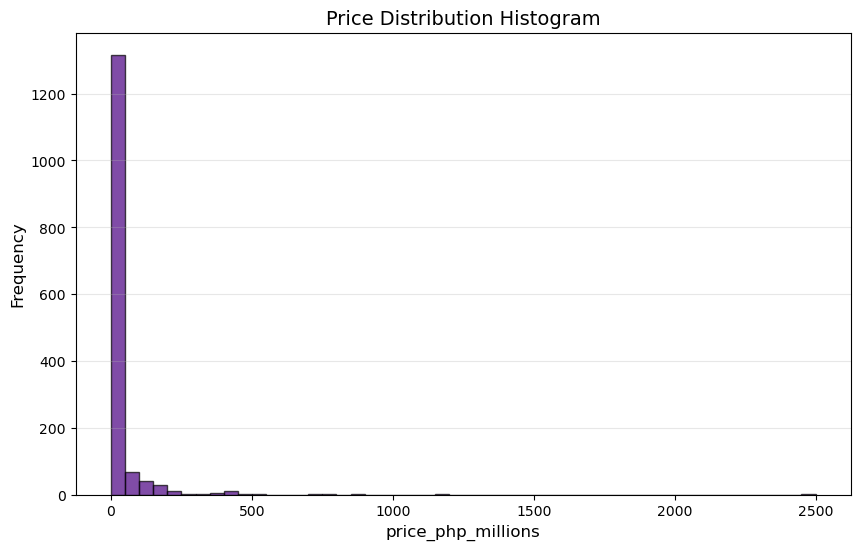

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df['price_php_millions'], bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.title('Price Distribution Histogram', fontsize=14)
plt.xlabel('price_php_millions', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### **Interpretation:** By the look of this histogram,the distribution of property prices is extremely skewed to the right. This means that most properties are concentrated at the lower price ranges, while a few very expensive properties are spread across the higher price ranges, creating a long right tail. This suggests the presence of high-priced outliers and great variation in property prices within the dataset.

### Price Brackets (Price Distribution Quantiles)

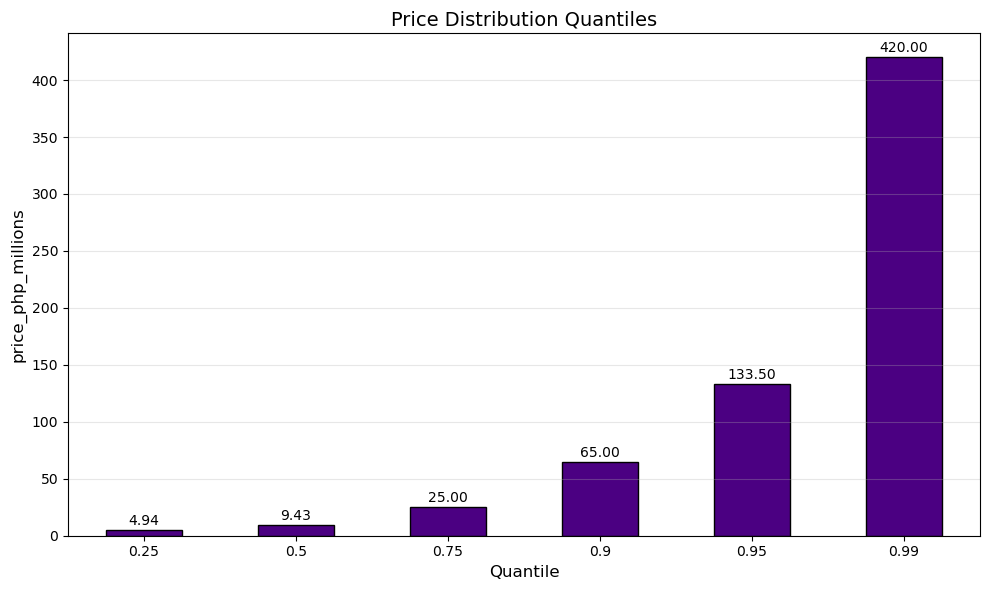

In [17]:
quantiles = df['price_php_millions'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
plt.figure(figsize=(10, 6))
quantiles.plot(kind='bar', color='indigo', edgecolor='black')
plt.title('Price Distribution Quantiles', fontsize=14)
plt.xlabel('Quantile', fontsize=12)
plt.ylabel('price_php_millions', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(quantiles):
    plt.text(i, v + (quantiles.max()*0.01), f'{v:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### **Interpretation:** These price distribution quantiles below show which a certain percentage of observations fall. Here, the top 95% of the data or properties have about greater than or equal to 132.75 million of price while the bottom 25% have price about less than or equal to 4.94 million.

## **SECTION 6: How Do Bathrooms or Bedrooms Make a Properties More Expensive?** (Bivariate Analysis)

In [18]:
# Create flags
df['has_bathroom'] = df['Bathrooms'].notna() & (df['Bathrooms'] > 0)
df['has_bedroom'] = df['Bedrooms'].notna() & (df['Bedrooms'] > 0)
df['has_neither'] = (~df['has_bathroom']) & (~df['has_bedroom'])
df['has_both'] = df['has_bathroom'] & df['has_bedroom']

bathroom_vs_price_df = (
    df[["has_bathroom", "price_php_millions"]]
    .groupby("has_bathroom")
    .agg(["mean", "median", "count", "skew"])
    .round(2)
    .sort_values(by=("price_php_millions", "mean"), ascending=False)
)

bedroom_vs_price_df = (
    df[["has_bedroom", "price_php_millions"]]
    .groupby("has_bedroom")
    .agg(["mean", "median", "count", "skew"])
    .round(2)
    .sort_values(by=("price_php_millions", "mean"), ascending=False)
)

neither_vs_price_df = (
    df[["has_neither", "price_php_millions"]]
    .groupby("has_neither")
    .agg(["mean", "median", "count", "skew"])
    .round(2)
    .sort_values(by=("price_php_millions", "mean"), ascending=False)
)

display(bathroom_vs_price_df)
display(bedroom_vs_price_df)
display(neither_vs_price_df)


price_php_millions                    
                           mean median count   skew
has_bathroom                                       
True                      33.73   9.80  1411  12.93
False                     13.86   3.98    80   4.13

price_php_millions                    
                          mean median count   skew
has_bedroom                                       
True                     33.66   9.84  1428  12.98
False                     9.98   3.70    63   5.29

price_php_millions                    
                          mean median count   skew
has_neither                                       
False                    33.49    9.8  1437  13.02
True                     10.63    3.8    54   4.90

##### **Interpretation:** Properties with both bathrooms and bedroom|s dominate the market (1,400+ listings) with a median price of 9.8 million pesos. Properties missing either room are lesser with only 54–80 listings and much cheaper, with medians of 3.7 million pesos – 4.0 million pesos. The high skew (12–13) across all categories means high priced estates pull average prices up, so the median is the more realistic measurement. Almost all properties have both rooms, meaning this dataset is primarily residential homes, not land or commercial spaces

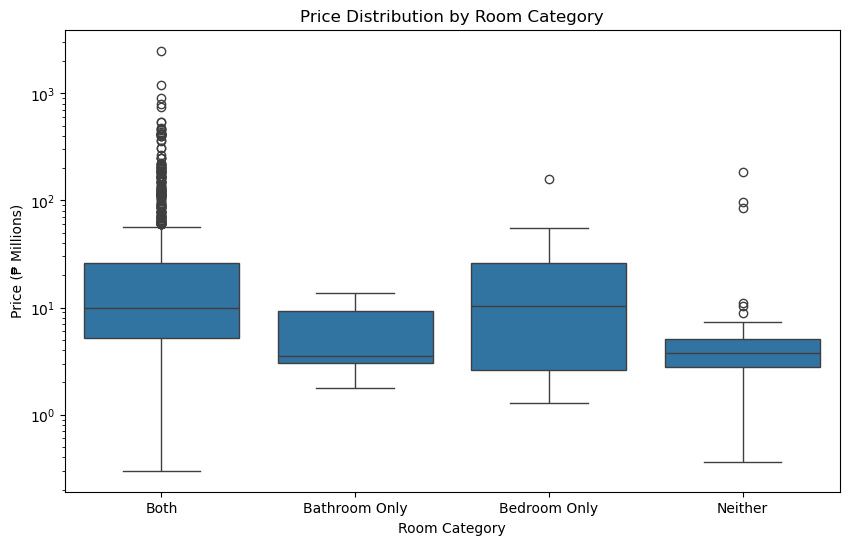

In [19]:
df['room_category'] = 'Neither'
df.loc[df['has_bathroom'] & ~df['has_bedroom'], 'room_category'] = 'Bathroom Only'
df.loc[~df['has_bathroom'] & df['has_bedroom'], 'room_category'] = 'Bedroom Only'
df.loc[df['has_bathroom'] & df['has_bedroom'], 'room_category'] = 'Both'

plt.figure(figsize=(10,6))
sns.boxplot(x='room_category', y='price_php_millions', data=df,
            order=['Both', 'Bathroom Only', 'Bedroom Only', 'Neither'])
plt.title('Price Distribution by Room Category')
plt.xlabel('Room Category')
plt.ylabel('Price (₱ Millions)')
plt.yscale('log')
plt.show()

##### **Interpretation:** The boxplot shows that properties with both bathrooms and bedrooms have the highest price spread and the highest median (around 10M). Bathroom-only and bedroom-only properties have lower medians (around 4 million pesos – 5 million pesos) but still show some high positive outliers. The *neither* has the tightest spread and lowest prices, consistent with vacant lots or raw land. 

## **SECTION 7: Prices Across Provinces** (Geographic Analysis)

### Where are properties most expensive?

In [20]:
luxury_threshold = df['price_php_millions'].quantile(0.95)
df[df['price_php_millions'] > luxury_threshold].groupby(['Province/NCR', 'Municipality/City'])['price_php_millions'].mean().sort_values(ascending=False).head(10)

Province/NCR       Municipality/City
Metro Manila       Makati City          660.777778
                   Muntinlupa           318.013889
                   Quezon City          270.035000
                   Manila               250.000000
Surigao del Norte  General Luna         250.000000
Cebu               Cebu City            220.000000
Pampanga           Angeles              220.000000
Batangas           Batangas City        200.000000
Metro Manila       Taguig               170.250000
                   Pasig                163.500000
Name: price_php_millions, dtype: float64

##### **Interpretation:** This table shows the average price of properties per Municipality/City from the top 95% of the listings. We got here Makati being the most expensive of about 721 million peses followed by Muntinlupa and so on. 

### Where are properties cheapest?

In [21]:
#what price is considered cheap
affordable_threshold = df['price_php_millions'].quantile(0.10)
# Sorted by mean price
df[df['price_php_millions'] < luxury_threshold].groupby(['Province/NCR', 'Municipality/City'])['price_php_millions'].mean().sort_values(ascending=True).head(10)

Province/NCR       Municipality/City
Zamboanga del Sur  Pagadian City        0.3000
Tarlac             Santa Ignacia        0.3600
Bulacan            Pandi                1.4900
Cebu               San Fernando         1.5000
Pampanga           Porac                1.5450
Rizal              Morong               1.6000
Bulacan            Baliwag              1.6700
Bataan             Limay                1.6700
Bukidnon           Manolo Fortich       1.7000
Bulacan            San Rafael           1.7475
Name: price_php_millions, dtype: float64

##### **Interpretation:** This table on the other hand shows the average price of properties per Municipality/City from the bottom 10% of the listings. We got here Pagadian City Zamboanga del Sur being the least expensive of about 0.300 million pesos or 300,000 pesos followed by Santa Ignacia, Tarlac and so on. 

### Where are properties most expensive per square meter? 

In [22]:
df['price_per_sqm'] = df['price_php_millions'] / df['Floor Area']
expensive_areas = df[df['price_per_sqm'] > df['price_per_sqm'].quantile(0.95)].groupby(['Province/NCR', 'Municipality/City'])['price_per_sqm'].agg(['mean']).sort_values('mean').head(10)
expensive_areas

mean
Province/NCR      Municipality/City          
Batangas          Batangas City      0.285714
Metro Manila      Mandaluyong City   0.292683
                  Pasig              0.311376
                  Manila             0.312500
                  Taguig             0.328643
                  Muntinlupa         0.358474
                  Quezon City        0.513237
                  Makati City        0.624716
Surigao del Norte General Luna       1.250000

##### **Interpretation:** This table shows the average price of properties per square meter of Municipality/City from the top 95% of the listings. We got here Batangas City being the most expensive of about 0.286 million peses or 285,714 pesos followed by Mandaluyong City and so on. 

### Where are properties least expensive per square meter? 

In [23]:
df['price_per_sqm'] = df['price_php_millions'] / df['Floor Area']
cheap_areas = df[df['price_per_sqm'] < df['price_per_sqm'].quantile(0.10)].groupby(['Province/NCR', 'Municipality/City'])['price_per_sqm'].agg(['mean']).sort_values('mean').head(10)
cheap_areas

mean
Province/NCR      Municipality/City          
Zamboanga del Sur Pagadian City      0.003750
Tarlac            Santa Ignacia      0.005625
Laguna            Lumban             0.013889
                  Majayjay           0.014005
                  Los Baños          0.015160
                  Cabuyao City       0.016471
Metro Manila      Marikina           0.017844
Laguna            Pagsanjan          0.017904
Batangas          Calatagan          0.017991
Laguna            Pila               0.018774

##### **Interpretation:** This table shows the average price of properties per square meter of Municipality/City from the bottom 10% of the listings. We got here Pagadian City, Zamboanga del Sur being the most expensive of about 0.003750 million peseos or 3,750 pesos followed by Santa Ignacia, Tarlac and so on. 

## **SECTION 8: Inferential Statistics**

### Linear Regression

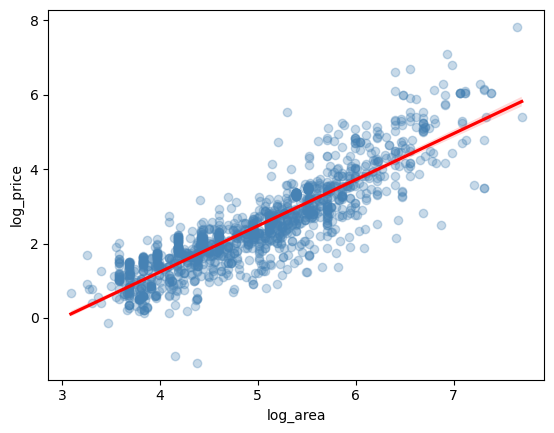

In [24]:
df['log_price'] = np.log(df['price_php_millions'])
df['log_area'] = np.log(df['Floor Area'])
df_linear = df.dropna(subset=['log_price', 'log_area'])

sns.regplot(x='log_area', y='log_price', data=df, 
            scatter_kws={'alpha':0.3, 'color':'steelblue'}, 
            line_kws={'color':'red'})

plt.show()

In [25]:
X = df_linear['log_area']
y = df_linear['log_price']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     4827.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:57:44   Log-Likelihood:                -1308.1
No. Observations:                1454   AIC:                             2620.
Df Residuals:                    1452   BIC:                             2631.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.7242      0.090    -41.451      0.0

##### **Interpretation:** What these all mean is that larger properties tend to have higher prices. This model shows that floor area explains about 77% of the variation in property prices (R² = 0.77). The coefficient indicates that a 1% increase in floor area is associated with about 1.24% increase in price. 
##### The relationship is statistically significant (p < 0.001), meaning that the observed effect is not unlikely by chance. The model may not explain all price variation so there are other factors contributing to the relationship where the other 23% can maybe explained by other factors such as locations, structural condition, and neighborhood qualities. 

